# 08 - Explainable Risk Modelling

We use **SHAP** to explain the LightGBM violence and arrest classifiers, and **permutation importance** as a model-agnostic check.

In [1]:
# bootstrap: make src importable
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pickle
import pandas as pd
from src import config, classification, explainability
inc = pd.read_parquet(config.FEATURES_DIR / 'incident_features.parquet')
with open(config.MODELS_DIR / 'is_violent_lgbm.pkl', 'rb') as f:
    pipe_violent = pickle.load(f)
with open(config.MODELS_DIR / 'is_arrest_lgbm.pkl', 'rb') as f:
    pipe_arrest = pickle.load(f)

## SHAP summary - violence classifier

C:\Users\cemil\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


02:08:48 | INFO    | src.explainability | SHAP summary -> C:\Users\cemil\Desktop\dataminingproject-01\reports\figures\nb_shap_violent.png


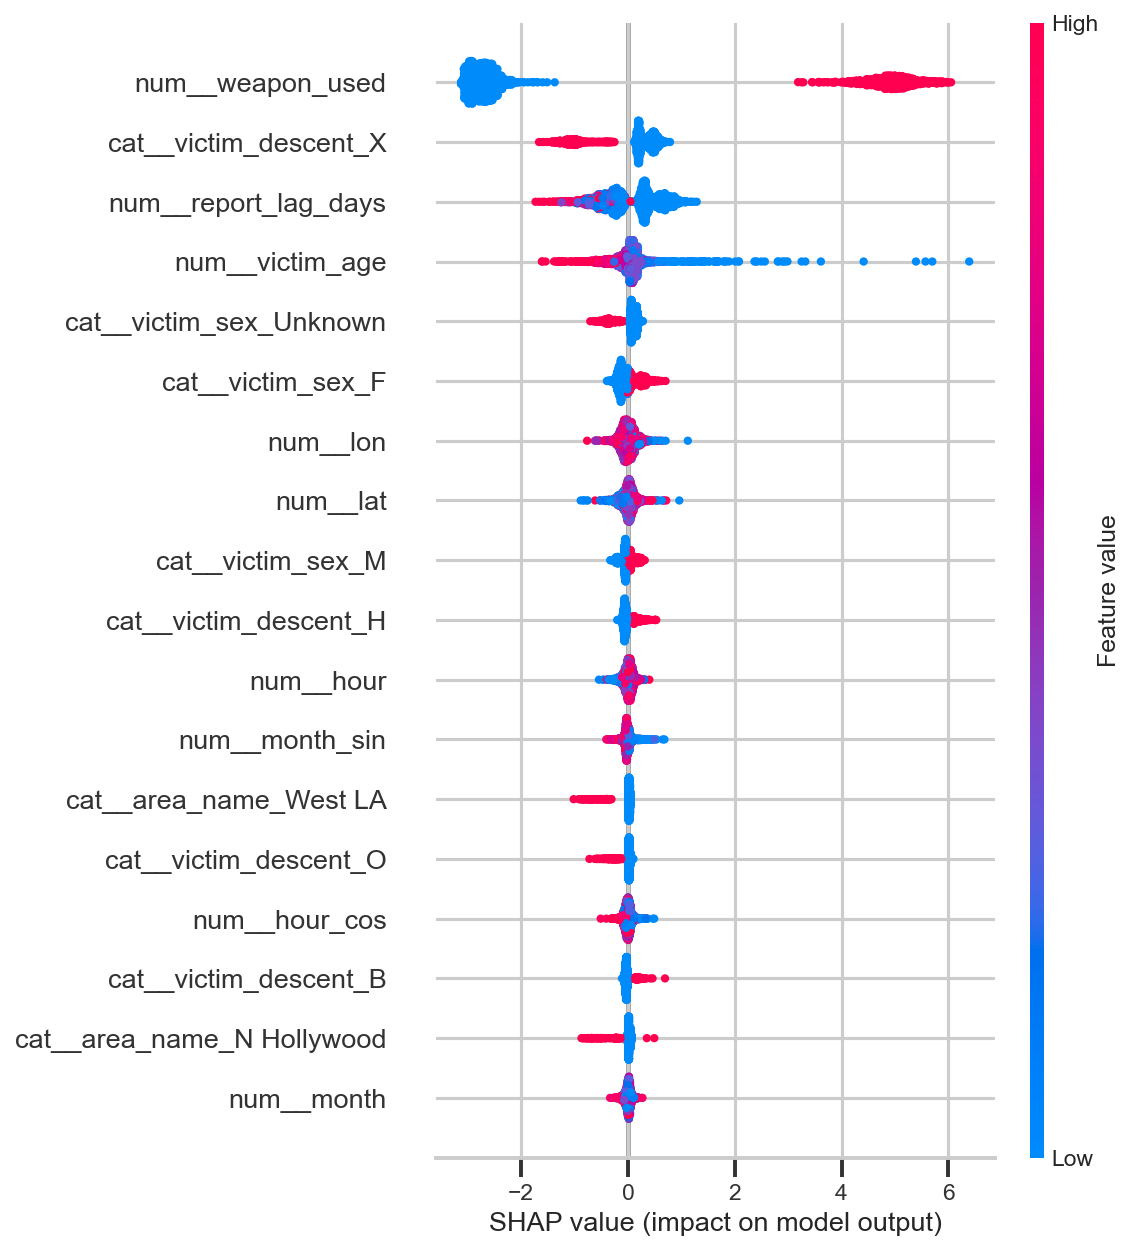

In [2]:
X_v = inc.dropna(subset=['is_violent'])[classification.NUMERIC + classification.CATEGORICAL]
path = explainability.shap_summary(pipe_violent, X_v, fname='nb_shap_violent', sample=2500)
from IPython.display import Image, display
display(Image(str(path)))

## SHAP summary - arrest classifier

C:\Users\cemil\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


02:08:51 | INFO    | src.explainability | SHAP summary -> C:\Users\cemil\Desktop\dataminingproject-01\reports\figures\nb_shap_arrest.png


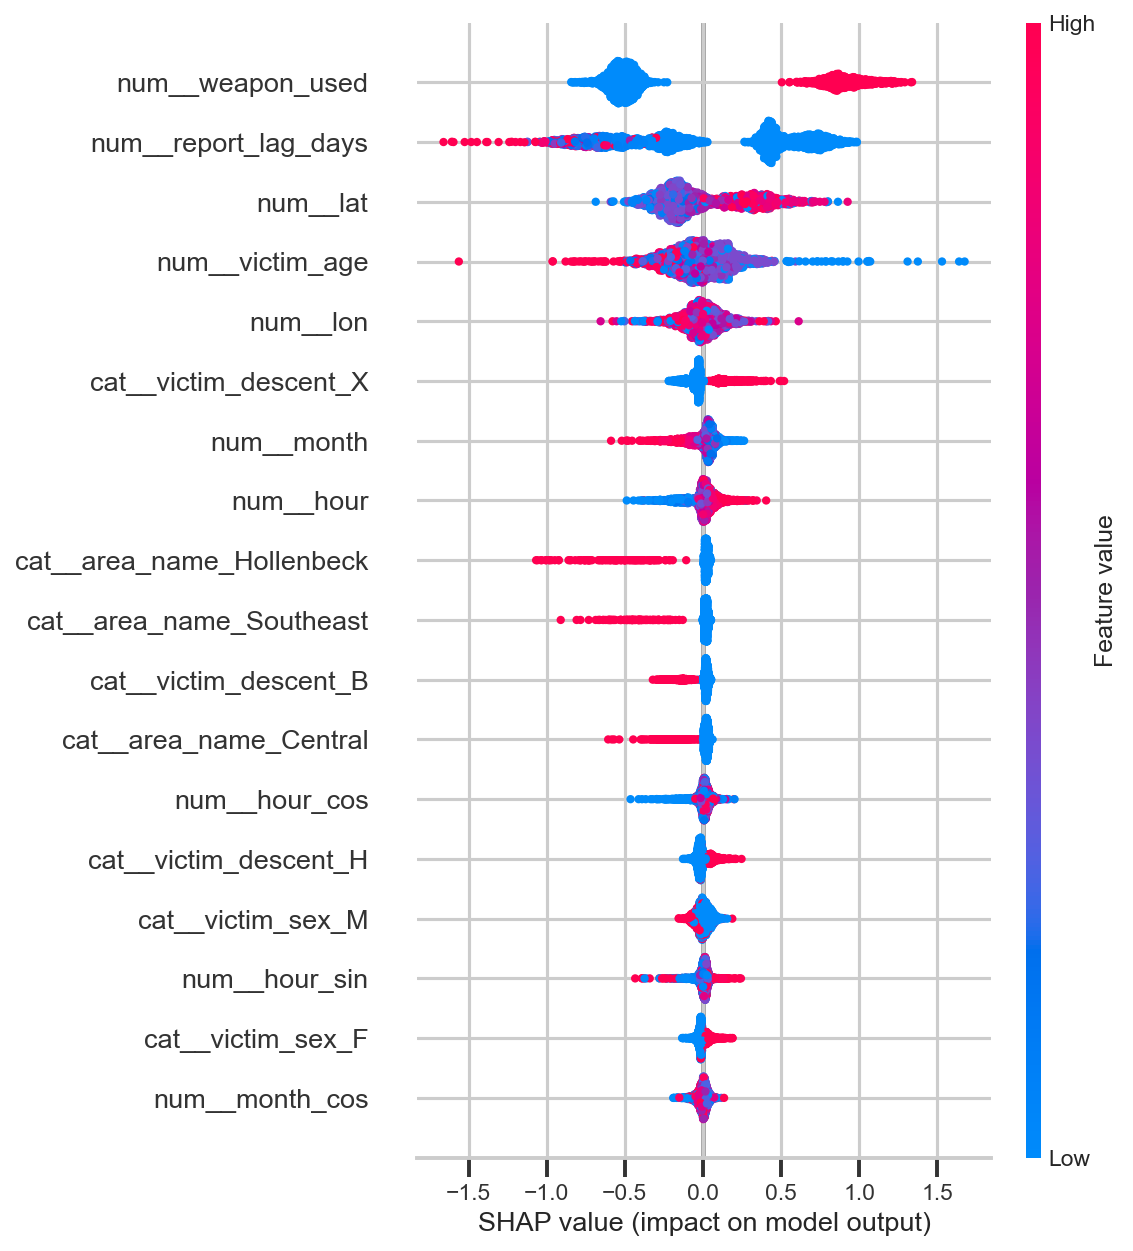

In [3]:
X_a = inc.dropna(subset=['is_arrest'])[classification.NUMERIC + classification.CATEGORICAL]
path = explainability.shap_summary(pipe_arrest, X_a, fname='nb_shap_arrest', sample=2500)
display(Image(str(path)))

## Permutation importance (model-agnostic, on a holdout sample)

In [4]:
Xs = X_v.sample(15000, random_state=42)
ys = inc.loc[Xs.index, 'is_violent']
explainability.permutation_top(pipe_violent, Xs, ys, top=12)

,feature,importance_mean,importance_std
0,weapon_used,0.300501,0.006235
1,victim_sex,0.018382,0.001099
2,lon,0.017651,0.000796
3,lat,0.015639,0.000539
4,victim_age,0.013350,0.000675
5,area_name,0.012175,0.000612
6,victim_descent,0.010652,0.000482
7,report_lag_days,0.008436,0.000225
8,hour,0.004187,0.000140
9,hour_cos,0.003143,0.000137


## Interpreting the findings

* **Violence drivers** — `weapon_used`, `victim_age`, `hour`, `area_name`, `part_of_day`   are consistently top features.
* **Arrest drivers** — `weapon_used`, `crime_desc` (via area/premise), and `victim_descent`   influence the model the most. Arrest decisions encode both the severity of the crime and   contextual factors, which matches the historical reality.
